# Implementation of MCP Neuron for AND and OR Function.


# For ”AND” Operations.


In [3]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)

  state_neuron = []

  # Element-wise addition + threshold check
  for i in range(len(X1)):
      s = X1[i] + X2[i]

      if s >= T:
          state_neuron.append(1)
      else:
          state_neuron.append(0)

  return state_neuron

In [4]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


# For ”OR” Operations.

In [5]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition + threshold check
    for i in range(len(X1)):
        s = X1[i] + X2[i]
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [6]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]



# 3.2.1 Answer the Following Question:

Question - 1: List out all the limitations of MCP - Neurons.

=

Can only solve linearly separable problems
It cannot work for non-linearly seperated data (OR and AND) not XOR.
Only binary input can be provided(0 or 1).
It cannot learn from data, weights must be manually saved.

Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron. = MCP neuron cannot solve XOR, we need multiple neurons (hidden layer) which leads to perceptron / neural networks

Since MCP uses inequality operators(logically), we can write the if else logic to solve XOR problem like:

if (x1 + x2 >= 1 AND x1 + x2 < 2) XOR = 1 else XOR = 0


# Task 2: Perceptron Algorithm for 0 vs 1 Classification.




## Step 1: Load the Dataset

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Question - 1: What does the shape of X represent?
= It means there are 12665 number of samples with 784 number of features per sample.

Question - 2: What does the shape of y represent?
= It means their are 12665 numbers of target label vectors.

### Viewing the Dataset.

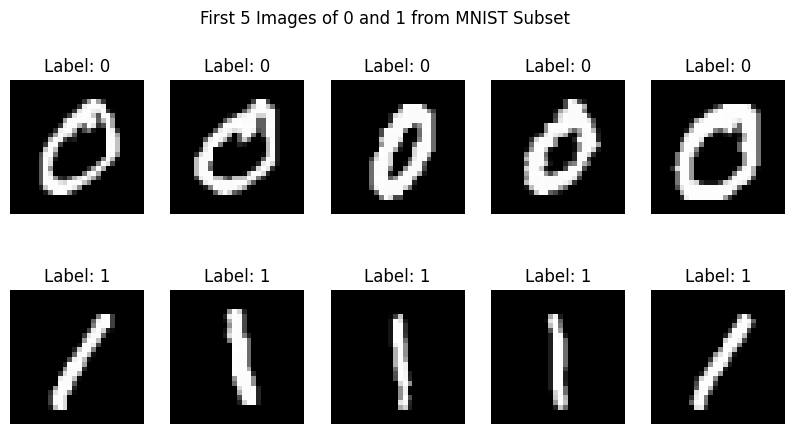

In [12]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [13]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Question - 3: What does the weights array represent in this context? = Represents the importance assigned to each of the 784 pixels.

Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?

= We initialize the weights to zero as a starting point before training begins. However, initializing all weights to zero can be problematic because all neurons will learn the same features during training, leading to no meaningful learning. Therefore, weights are usually initialized with small random values instead.

## Step - 3 - Make a Decision function:

In [15]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training
    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    # Step 1: Calculate the net input (weighted sum + bias)
    predictions = np.dot(X, weights) + bias

    # Step 2: Apply the step function (Activation function)
    # If prediction >= 0, return 1, else return 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all


## Step - 4 - Implement the Perceptron Learning Algorithm

In [16]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    for epoch in range(epochs):
        for i in range(len(X)):
          z = np.dot(X[i], weights) + bias
          y_hat = 1 if z >= 0 else 0

          if y_hat != y[i]:
            weights += learning_rate * (y[i] - y_hat) * X[i]
            bias += learning_rate * (y[i] - y_hat)

    # calculating the accuracy
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)
    print("Accuracy: ", accuracy)


    return weights, bias, accuracy

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

=It calculates the activation value (z) used to make a prediction. The weighted sum (linear combination) of inputs and weights.

np.dot(X[i], weights) - multiplies each feature with its weight and sums them

bias - shifts the decision boundary
Question 6: What happens when the prediction is wrong? How are weights and bias updated?

= When a prediction is wrong, it is firstly detected using loss function, then following steps are implemented:

partial derivative of loss function with respect to each weight is calculated

chain rule is used to do such calculations as the weights are never directly related to loss function.

then finally, each weight is updated by the difference of that weight to learning rate times the previous derivative relation.

Question 7: Why is the final accuracy important, and what do you expect it to be?

= The final accuracy is important in terms of judging how good the model we created is, it helps us determine things like:

if the model learnt from the data well
if we need more training data
if we need more epochs

## Training the Perceptron

In [17]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Accuracy:  1.0
The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [18]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Question 8: What does misclassified_idx store, and how is it used?

= misclassified_idx stores the indices (positions) of the samples that were predicted incorrectly by the model.

It is used to:

Identify which data points the model got wrong
Analyze errors and understand where the model is failing
Question 9: How do you interpret the result if the output is “All images were correctly classified!”?

=This means that the model made no mistakes during prediction.

Interpretation:Every input sample was classified correctly. The model achieved 100% accuracy on the dataset. It indicates perfect performance on that data

# Task 3: Perceptron Algorithm for 3 vs 5 Classification.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI/mnist_3_and_5.csv")

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values   # 784 pixel values
y = df_3_5["label"].values                  # Labels: 3 or 5


y_binary = np.where(y == 3, 0, 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape  : (2741,)


# step2:viewing the **dataset**

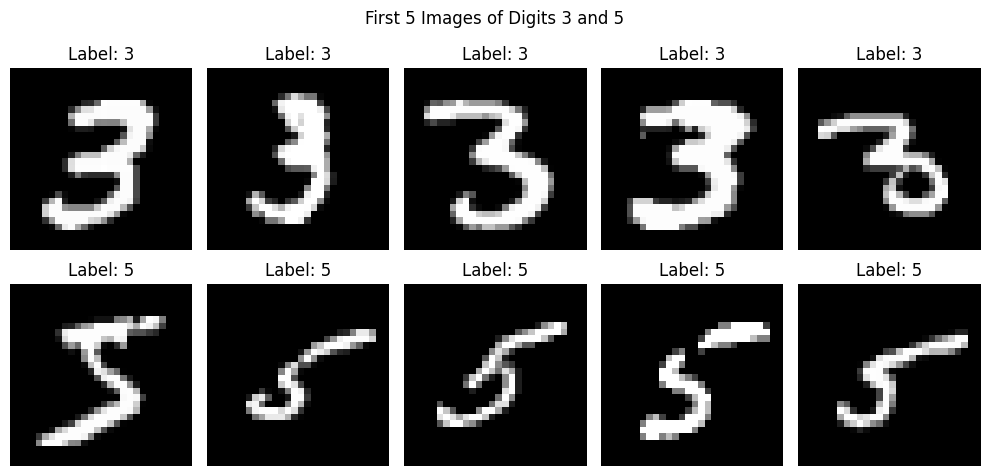

In [25]:
# Separate images by original label
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Not enough images to display 5 samples per class.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of Digits 3 and 5")
    plt.tight_layout()
    plt.show()


# Step 3: Initialise Weights and Bias

In [26]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

# Step 4: Decision Function (Activation Function)

In [27]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels using the perceptron step function.

    Parameters
    ----------
    X       : ndarray, shape (n_samples, n_features)
    weights : ndarray, shape (n_features,)
    bias    : float

    Returns
    -------
    y_pred_all : ndarray of 0s and 1s, shape (n_samples,)
    """
    predictions = np.dot(X, weights) + bias
    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 5, 3)

    return y_pred_all


# Step 5: Implement the Perceptron Learning Algorithm

In [28]:

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters
    ----------
    X             : ndarray (n_samples, n_features)  – pixel values
    y             : ndarray (n_samples,)              – binary labels {0, 1}
    weights       : ndarray (n_features,)             – initial weights
    bias          : float                             – initial bias
    learning_rate : float                             – η (step size)
    epochs        : int                               – max training passes

    Returns
    -------
    weights  : updated weight array
    bias     : updated bias scalar
    accuracy : final training accuracy (float 0–1)
    """
    for epoch in range(epochs):
        for i in range(len(X)):
          z = np.dot(X[i], weights) + bias
          y_hat = 1 if z >= 0 else -1

          if y_hat != y[i]:
            weights += learning_rate * (y[i] - y_hat) * X[i]
            bias += learning_rate * (y[i] - y_hat)

    # calculating the accuracy
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)
    print("Accuracy: ", accuracy)


    return weights, bias, accuracy

In [29]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Accuracy:  0.45859175483400216
The Final Accuracy is:  0.45859175483400216


# Step 7: Visualise Misclassified Images

Final Accuracy: 0.4586  (1257/2741 correct)
Number of misclassified images: 1484


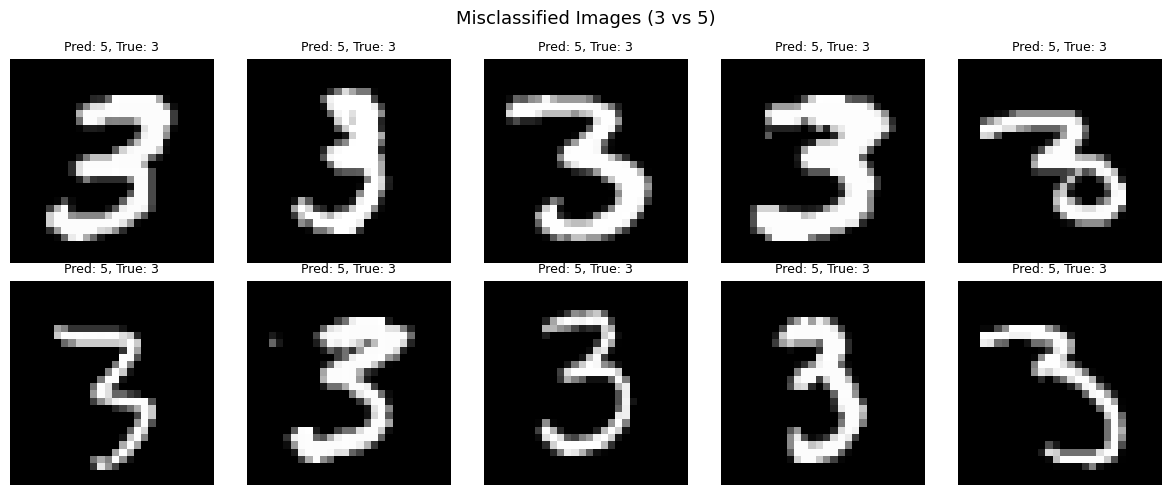

In [30]:
# Get predictions for the entire dataset
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

# Map binary predictions back to digit labels for display
y_pred_label = np.where(y_pred == 0, 3, 5)

# Final accuracy
final_accuracy = np.mean(y_pred == y_binary)
print(f"Final Accuracy: {final_accuracy:.4f}  ({int(final_accuracy * len(y_binary))}/{len(y_binary)} correct)")

# Identify misclassified samples
misclassified_idx = np.where(y_pred != y_binary)[0]
print(f"Number of misclassified images: {len(misclassified_idx)}")

if len(misclassified_idx) > 0:
    n_show = min(10, len(misclassified_idx))
    n_cols = 5
    n_rows = (n_show + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5))
    axes = axes.flatten()

    for ax_i, idx in enumerate(misclassified_idx[:n_show]):
        ax = axes[ax_i]
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred_label[idx]}, True: {y[idx]}", fontsize=9)
        ax.axis("off")

    # Hide unused axes
    for ax_i in range(n_show, len(axes)):
        axes[ax_i].axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")
